In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from asyncssh import forward
from sklearn.model_selection import train_test_split
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import re
import copy
from sklearn.decomposition import PCA
import seaborn as sns

In [15]:
data=pd.read_csv('dhi_medo_2c_30n/Dataset_medoids.csv')

# tokens - top_time model
vocab_top = ['-p', '+p', '-l', '+l', 'd']
vocab_seq = ['1', '2', '3', '4']
vocab = {}
token_id = 0

for t in vocab_top:
    for s in vocab_seq:
        fused = f'{t}_{s}'
        vocab[fused] = token_id
        token_id += 1


def tokenize_sequence(token, vocab):
    tokenized = []
    for i in range(3):  # Since sequences are exactly length 3
        fused_key = token[i]
        tokenized.append(vocab[fused_key])
    return tokenized



# Tokenize data
data['splited_top'] = data['top'].apply(lambda text: re.findall(r'[+-][pl]|d', str(text)))
data['splited_seq'] = data['seq'].apply(lambda text: re.findall(r'1|2|3|4', str(text)))

data['tokens'] = data.apply(lambda row: [f'{top}_{seq}' for top, seq in zip(row['splited_top'], row['splited_seq'])],
                            axis=1)
data['tokenased'] = data.apply(lambda row: tokenize_sequence(row['tokens'], vocab), axis=1)
data=data.drop(['top','seq','tokens', 'splited_top', 'splited_seq'], axis=1)



In [16]:
dih_data=data.drop(['tokenased', 'sredni_czas'], axis=1)
meth_data=data['tokenased']
time=data['sredni_czas']
pca=PCA(n_components=128)
dih_PCA=pca.fit_transform(dih_data)
pca_cols = [f'PC{i+1}' for i in range(128)]
df_dih_PCA=pd.DataFrame(dih_PCA, columns=pca_cols, index=dih_data.index)
data=pd.concat([meth_data, df_dih_PCA], axis=1)
data=pd.concat([data, time], axis=1)
print(data.head(5))
print(np.cumsum(pca.explained_variance_ratio_)[-1])

    tokenased       PC1       PC2       PC3       PC4       PC5       PC6  \
0  [9, 3, 11] -1.663852 -0.039450  0.818656  0.730087  1.515799  0.674291   
1  [9, 3, 11] -1.705920 -0.033666  0.747576  0.253751  0.618163  0.498571   
2  [9, 3, 11] -1.851037 -0.012796  0.554108  0.164327  0.917758  0.683400   
3  [9, 3, 11] -1.761718  0.014094  0.603069  0.792039  1.123803  0.841325   
4  [9, 3, 11] -1.488965  0.073078  1.825265  0.149957  1.143413  0.988637   

        PC7       PC8       PC9  ...     PC120     PC121     PC122     PC123  \
0  0.593883 -2.358862  0.150413  ... -0.013808 -0.619365  0.066278  0.540365   
1  0.092681 -2.325760  0.570132  ...  0.110555 -0.748224 -0.098733  0.152375   
2  0.498099 -2.195665  0.114712  ... -0.194192 -0.421894 -0.232096  0.099115   
3  0.216882 -2.665599  0.497266  ...  0.141630 -0.772753  0.213105  0.737689   
4  0.260981 -2.376685  0.426761  ... -0.439604 -1.135303 -0.143708  0.239481   

      PC124     PC125     PC126     PC127     PC128    s

In [17]:
# podział na set nowy
train, test = train_test_split(data, test_size=0.0075)
test_fin = data[data['tokenased'].isin(test['tokenased'])].reset_index(drop=True)
train_fin = train[~train['tokenased'].isin(test_fin['tokenased'])].reset_index(drop=True)

X_test=test_fin.drop(['sredni_czas'], axis=1)
Y_test=test_fin['sredni_czas']

train_set, val_set = train_test_split(train_fin, test_size=0.1)
X_train = train_set.drop(['sredni_czas'], axis=1)
X_val = val_set.drop(['sredni_czas'], axis=1)
Y_train = train_set['sredni_czas']
Y_val = val_set['sredni_czas']

# Tensory Y
Y_train_ten=torch.tensor(Y_train.to_numpy(), dtype=torch.float)
Y_val_ten=torch.tensor(Y_val.to_numpy(), dtype=torch.float)
Y_test_ten=torch.tensor(Y_test.to_numpy(), dtype=torch.float)

# przygotowanie danych wejściowych dla modelu token --> time
X_train_tok=X_train['tokenased']
X_val_tok=X_val['tokenased']
X_test_tok=X_test['tokenased']

# przygotowanie danych wejciowych dla modelu kąt --> time
X_train_ang=X_train.drop(['tokenased'], axis=1)
X_val_ang=X_val.drop(['tokenased'], axis=1)
X_test_ang=X_test.drop(['tokenased'], axis=1)

batch=32

# Tensory wejściowe token --> time
X_ten_train_tok=torch.tensor(X_train_tok.tolist(), dtype=torch.long)
X_ten_val_tok=torch.tensor(X_val_tok.tolist(), dtype=torch.long)
X_ten_test_tok=torch.tensor(X_test_tok.tolist(), dtype=torch.long)


# Tensory wejściowe kat --> time
X_ten_train_ang=torch.tensor(X_train_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_val_ang=torch.tensor(X_val_ang.astype('float32').to_numpy(), dtype=torch.float)
X_ten_test_ang=torch.tensor(X_test_ang.astype('float32').to_numpy(), dtype=torch.float)

# jednen dataset i dataloader dla połączonego modelu
train_ds_comb=TensorDataset(X_ten_train_tok, X_ten_train_ang, Y_train_ten)
train_loader_comb=DataLoader(train_ds_comb, batch_size=batch, shuffle=True)
val_ds_comb=TensorDataset(X_ten_val_tok, X_ten_val_ang, Y_val_ten)
val_loader_comb=DataLoader(val_ds_comb, batch_size=batch, shuffle=False)
#test_ds_comb=TensorDataset(X_ten_test_tok, X_ten_test_ang, Y_test)
#test_loader_comb=DataLoader(test_ds_comb, batch_size=batch, shuffle=False)

In [18]:

# tego nie tykać bo już jest wytrnowany
class GQuadTimeToken(nn.Module):
    def __init__(self, vocab_size=20, embedding_dim=6, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)
        flattened_size = 3 * embedding_dim
        self.fc1 = nn.Linear(flattened_size, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(p=0.15)
        self.fc4 = nn.Linear(32, 8)
        self.fc5 = nn.Linear(8, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        x = embedded.view(embedded.size(0), -1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        x = self.dropout(x)
        x = self.fc4(x)
        Model_A_out = x
        return Model_A_out

# tu moge zmieniać ile chce
class GQuadTimeAng(nn.Module):
    def __init__(self):
        super(GQuadTimeAng, self).__init__()
        self.fc1=nn.Linear(128, 64)
        self.fc4=nn.Linear(64,32)
        self.fc6=nn.Linear(32,16)
        self.fc5=nn.Linear(16,1)


        # Activation and drop function
        self.re=nn.ReLU()
        self.drop=nn.Dropout(p=0.2)
        self.bn1=nn.BatchNorm1d(128)


    def forward(self, x):
        x=self.re(self.fc1(x))
        x=self.drop(x)
        x=self.re(self.fc4(x))
        x=self.fc6(x)

        out=x
        return out

class GQuadComb(nn.Module):
    def __init__(self, model_a, model_b):
        super(GQuadComb, self).__init__()
        self.model_a = model_a
        self.model_b = model_b

        self.bnA=nn.BatchNorm1d(8)
        self.bnB=nn.BatchNorm1d(16)

        for param in self.model_a.parameters():
            param.requires_grad = False

        for param in self.model_b.parameters():
            param.requires_grad = False

        self.endmodel=nn.Sequential(
            nn.Linear(24, 8),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(8,4),
            nn.ReLU(),
            nn.Linear(4,1),
        )
    def forward(self, input_a, input_b):
        out_a = self.model_a(input_a)
        out_b = self.model_b(input_b)
        out_a = self.bnA(out_a)
        out_b = self.bnB(out_b)

        com_input = torch.cat((out_a, out_b), 1)
        output = self.endmodel(com_input)
        return output

model_a = GQuadTimeToken()
model_a.load_state_dict(torch.load('modele - wytrenowane/model_toptime_good_ps.pth'))
model_b = GQuadTimeAng()
model_b.load_state_dict(torch.load('modele - wytrenowane/model_angPCAtime_good.pth'))
model_fin=GQuadComb(model_a, model_b)
model_fin.load_state_dict(torch.load('modele - wytrenowane/endmodel_struct_PCAangel.pth'))

<All keys matched successfully>

--- FINAL EXAM RESULTS ---
On average, the model is off by: 160746.56 time units
R-squared Score (Accuracy proxy): 0.55


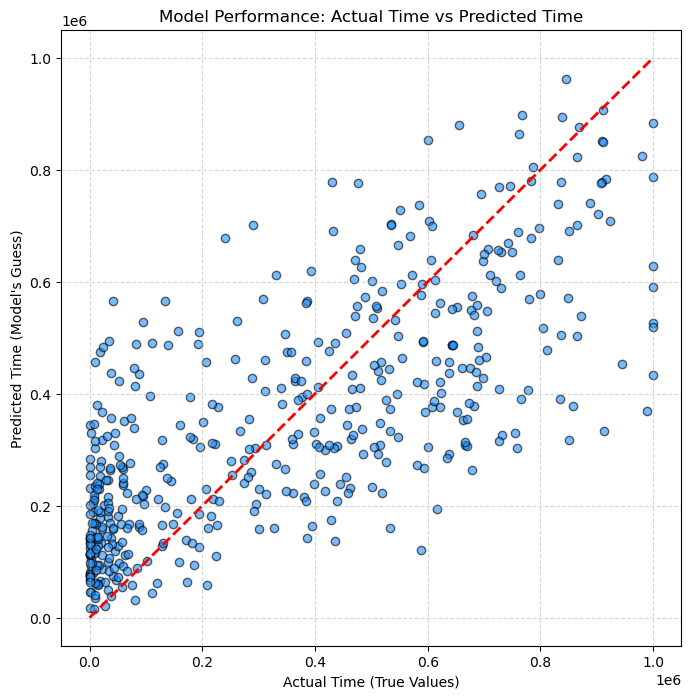

In [19]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_tok, X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()
df_preds=pd.DataFrame({
    'Tokens': [tuple(x) for x in X_ten_test_tok.numpy()],
    'Predictions':preds.flatten(),
    'Actuals':actuals.flatten()
})

zest=df_preds.groupby(['Tokens']).agg(
    avg_preds=('Predictions','mean'),
    median_preds=('Predictions','median'),
    actuals=('Actuals','mean')
)

#preds=zest['median_preds']
preds=zest['avg_preds']
actuals=zest['actuals']


# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- FINAL EXAM RESULTS ---
On average, the model is off by: 173181.58 time units
R-squared Score (Accuracy proxy): 0.45


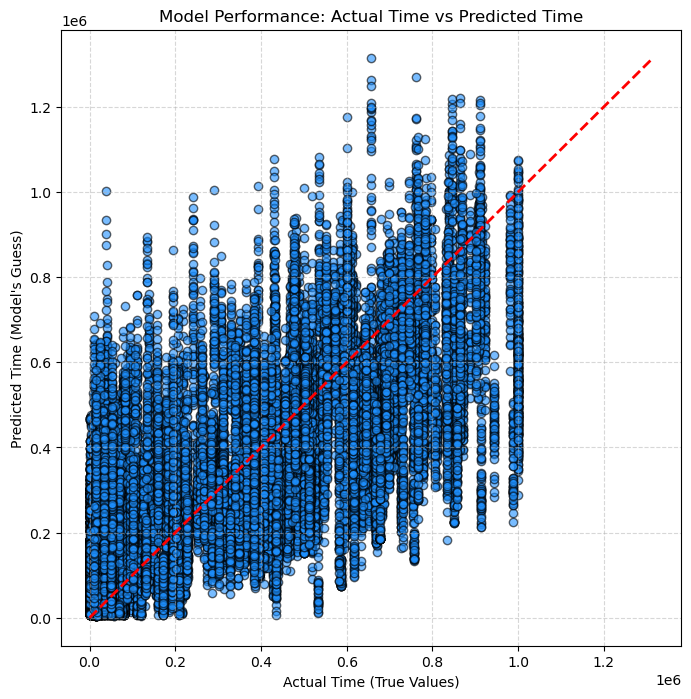

In [20]:
# 1. Put the model into evaluation mode (turns off training features)
model_fin.eval()

# 2. Make predictions on the completely unseen TEST data
with torch.no_grad():
    test_predictions = model_fin(X_ten_test_tok, X_ten_test_ang)

# 3. Convert PyTorch Tensors back to normal Numpy arrays
# (Matplotlib and Sklearn prefer normal arrays)
actuals = Y_test_ten.numpy()
preds = test_predictions.numpy()
df_preds=pd.DataFrame({
    'Tokens': [tuple(x) for x in X_ten_test_tok.numpy()],
    'Predictions':preds.flatten(),
    'Actuals':actuals.flatten()
})


# 4. Calculate "Human-Readable" Scores
# MAE (Mean Absolute Error): On average, how many units of time is the prediction wrong by?
mae = mean_absolute_error(actuals, preds)

# R2 Score: A percentage of how well the model fits the data (1.0 is perfect, 0.0 is terrible)
r2 = r2_score(actuals, preds)

print("--- FINAL EXAM RESULTS ---")
print(f"On average, the model is off by: {mae:.2f} time units")
print(f"R-squared Score (Accuracy proxy): {r2:.2f}")

# 5. Draw the "Actual vs. Predicted" Plot
plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.6, color='dodgerblue', edgecolors='k')

# Draw a red diagonal line. If the model is perfect, all blue dots will sit exactly on this red line.
min_val = min(actuals.min(), preds.min())
max_val = max(actuals.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

# Make the plot look nice
plt.title("Model Performance: Actual Time vs Predicted Time")
plt.xlabel("Actual Time (True Values)")
plt.ylabel("Predicted Time (Model's Guess)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
print(X_train)

         tokenased       PC1       PC2       PC3       PC4       PC5  \
5867     [8, 3, 8] -0.789981 -1.068385  0.865791  1.504539  0.728536   
14357  [15, 17, 1]  0.928865  0.119914  0.975163 -0.470806  0.516972   
14342   [8, 0, 11] -1.352007 -0.919363 -0.647051 -0.903620  0.684522   
3844     [3, 1, 2]  0.504719  0.375433 -0.200806 -1.118444 -1.436197   
9849    [1, 18, 5]  0.457681 -1.283694  0.047545  1.311245 -1.626972   
...            ...       ...       ...       ...       ...       ...   
6419     [9, 2, 8] -0.303819 -1.294996  1.971344  1.295298 -0.283510   
10187  [12, 5, 15] -0.247743 -0.901376 -1.309249 -0.722628 -0.834759   
104      [8, 0, 2] -0.555377 -1.174929  0.039757  2.662393  0.827160   
12553   [13, 4, 6]  0.321078 -2.040302  0.431910  0.158400  0.873709   
572     [3, 16, 5] -0.520927  0.619642 -2.042864  0.993117 -1.084080   

            PC6       PC7       PC8       PC9  ...     PC119     PC120  \
5867   1.070096  0.410314  0.426780  0.089637  ...  0.290918 